LINEAR REGRATION PRACTICE 

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Toyoto_Corrola.csv", index_col=0)

In [3]:
data.head()

,Model,Price,Age_08_04,KM,HP,Doors,Cylinders,Gears,Weight
Id,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,46986,90,3,4,5,1165
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,72937,90,3,4,5,1165
3,ÊTOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,41711,90,3,4,5,1165
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,48000,90,3,4,5,1165
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,38500,90,3,4,5,1170


In [53]:
data.isnull().sum()

Model        0
Price        0
Age_08_04    0
KM           0
HP           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [54]:
import matplotlib.pyplot as plt

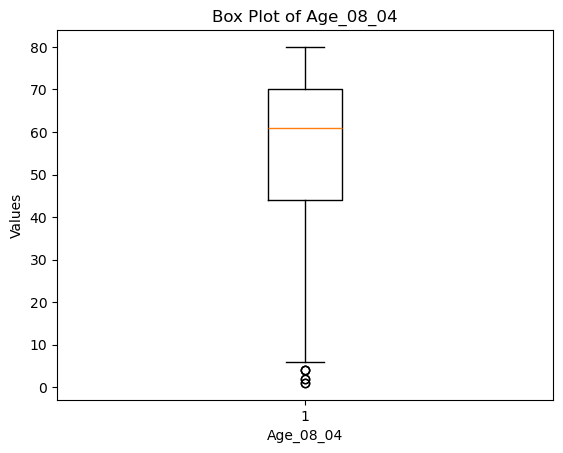

In [55]:
plt.boxplot(data['Age_08_04'])
plt.xlabel('Age_08_04')
plt.ylabel('Values')
plt.title('Box Plot of Age_08_04')
plt.show()

In [56]:
colname = []
for x in data.columns:
    if data[x].dtype == 'object':
        colname.append(x)
colname

['Model']

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for x in colname:
    data[x] = le.fit_transform(data[x])

    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('Mapping:', le_name_mapping)

Feature Model
Mapping: {'TOYOTA Corolla ': np.int64(0), 'TOYOTA Corolla ! 1.6-16v vvt-i sol airco sedan 4/5-Doors': np.int64(1), 'TOYOTA Corolla 1 6-16v VVT-i Linea Terra Comfort Airco 5drs 4/5-Doors': np.int64(2), 'TOYOTA Corolla 1.3 16V 2/3-Doors': np.int64(3), 'TOYOTA Corolla 1.3 16V HATCHB 2/3-Doors': np.int64(4), 'TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors': np.int64(5), 'TOYOTA Corolla 1.3 16V HATCHB LINEA LUNA 2/3-Doors': np.int64(6), 'TOYOTA Corolla 1.3 16V HATCHB LINEA LUNA AUT3 2/3-Doors': np.int64(7), 'TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors': np.int64(8), 'TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA AUT3 2/3-Doors': np.int64(9), 'TOYOTA Corolla 1.3 16V HATCHB S 2/3-Doors': np.int64(10), 'TOYOTA Corolla 1.3 16V L. TERRA COMFORT 2/3-Doors': np.int64(11), 'TOYOTA Corolla 1.3 16V LB Linea Luna 4/5-Doors': np.int64(12), 'TOYOTA Corolla 1.3 16V LIFTB G6 4/5-Doors': np.int64(13), 'TOYOTA Corolla 1.3 16V LIFTB LINEA LUNA 4/5-Doors': np.int64(14), 'TOYOTA Corolla 1.3 16V L

In [58]:
import seaborn as sns

<Axes: >

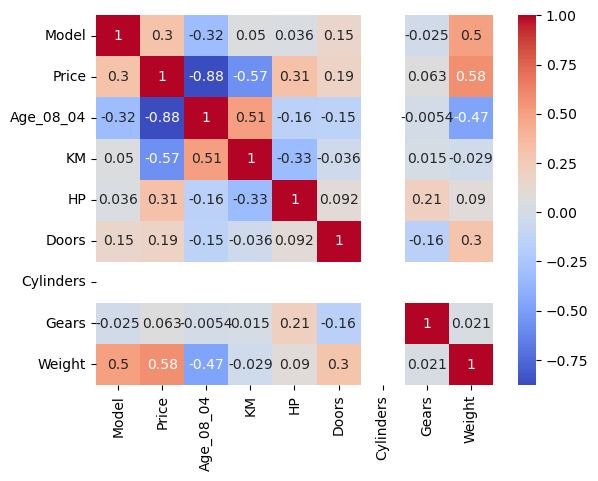

In [59]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
x = data [['Model','Age_08_04', 'KM', 'HP', 'Cylinders', 'Doors', 'Gears', 'Weight']]
y = data['Price']

In [62]:
x.head()

,Model,Age_08_04,KM,HP,Cylinders,Doors,Gears,Weight
Id,,,,,,,,
1,257,23,46986,90,4,3,5,1165
2,257,23,72937,90,4,3,5,1165
3,365,24,41711,90,4,3,5,1165
4,257,26,48000,90,4,3,5,1165
5,256,30,38500,90,4,3,5,1170


In [63]:
y.head()

Id
1    13500
2    13750
3    13950
4    14950
5    13750
Name: Price, dtype: int64

In [64]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [65]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 8)
(288, 8)
(1148,)
(288,)


In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
print ('Beta Values: ', model.coef_)
print ('Intercept: ', model.intercept_)

Beta Values:  [-2.10456811e+00 -1.20688162e+02 -1.88995608e-02  2.99982909e+01
 -4.15667500e-13 -4.78528562e+01  4.40432670e+02  2.35082489e+01]
Intercept:  -11219.512652554506


In [69]:
y_pred = model.predict(x_test)

In [70]:
x_test.head()

,Model,Age_08_04,KM,HP,Cylinders,Doors,Gears,Weight
Id,,,,,,,,
1026,21,68,33847,86,4,4,5,1000
304,107,43,39650,110,4,3,5,1055
373,121,39,18500,110,4,4,5,1030
896,81,57,61000,110,4,3,5,1050
1157,93,78,100487,110,4,4,5,1035


In [71]:
x_test["actual_sales"] = y_test
x_test["predicted_sales"] = y_pred
print(x_test)

      Model  Age_08_04      KM   HP  Cylinders  Doors  Gears  Weight  \
Id                                                                     
1026     21         68   33847   86          4      4      5    1000   
304     107         43   39650  110          4      3      5    1055   
373     121         39   18500  110          4      4      5    1030   
896      81         57   61000  110          4      3      5    1050   
1157     93         78  100487  110          4      4      5    1035   
...     ...        ...     ...  ...        ...    ...    ...     ...   
624     128         68  140000  110          4      5      5    1085   
39       51         32   25329   97          4      3      5    1100   
556     348         49   41636  110          4      5      5    1105   
628      85         67  135337  110          4      5      5    1120   
470     126         56   66777  110          4      5      5    1090   

      actual_sales  predicted_sales  
Id                       

## Model evaluation with RMSE
Root Mean Squared Error (RMSE) tells us how close the model predictions are to the actual values.\
- `y_test` contains actual prices.\
- `y_pred` contains predicted prices from the model.\
- RMSE is the square root of the average squared difference between actual and predicted values.\
- A lower RMSE means better predictions.

In [72]:
from sklearn.metrics import root_mean_squared_error

# Calculate RMSE using actual and predicted values
rmse = root_mean_squared_error(y_test, y_pred)
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 1550.9760021330917


In [73]:
# RMSE is already calculated above, this cell can be used to reuse the value if needed
print('RMSE value from previous cell:', rmse)

RMSE value from previous cell: 1550.9760021330917


In [74]:
import joblib 
joblib.dump(model, '4_practice_LR_model.pkl')

['4_practice_LR_model.pkl']